# Modelo Bayesiano para la Pesca de Jurel en Atacama — **Modelo 0**

Este notebook es el primero de una serie de modelos bayesianos para inferir la captura diaria de *jurel* por parte de las *lanchas* en la región de Atacama.

**La pregunta de investigación eventual** es:

> *¿Cuál fue la captura diaria latente de cada lancha, dado que solo observamos el agregado semanal, las trayectorias diarias de GPS/velocidad y las condiciones climáticas diarias?*

## 0. Setup

In [98]:
%pip install numpy pandas pymc arviz matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [99]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
az.style.use("arviz-darkgrid")
rng = np.random.default_rng(42)

In [100]:
DATA_PATH = "data/landings/weekly_desembarques.csv"

weekly_data = pd.read_csv(DATA_PATH, sep=",")
weekly_data.head()

,bulletin_number,start_date,end_date,anchoveta_t,jurel_t,sardina_espanola_t,caballa_t
0,1,2023-01-02,2023-01-08,0,0,0,0
1,2,2023-01-09,2023-01-15,0,0,0,0
2,3,2023-01-16,2023-01-22,0,0,0,0
3,4,2023-01-23,2023-01-29,0,0,0,0
4,5,2023-01-30,2023-02-05,0,1827,0,48


## 1. Exploración de Datos: Llegada de Jurel
Exploraremos la variable objetivo: la captura semanal de jurel. Este es el dato que queremos modelar, aunque en el futuro lo haremos a nivel diario y por lancha. Por ahora, solo nos interesa entender su distribución marginal.

In [101]:
# Derivar columnas de tiempo desde start_date para agrupar.
weekly_data["start_date"] = pd.to_datetime(weekly_data["start_date"])
weekly_data["mes"] = weekly_data["start_date"].dt.month_name(locale="es_ES.UTF-8") \
    if False else weekly_data["start_date"].dt.month  # mes numérico evita locale

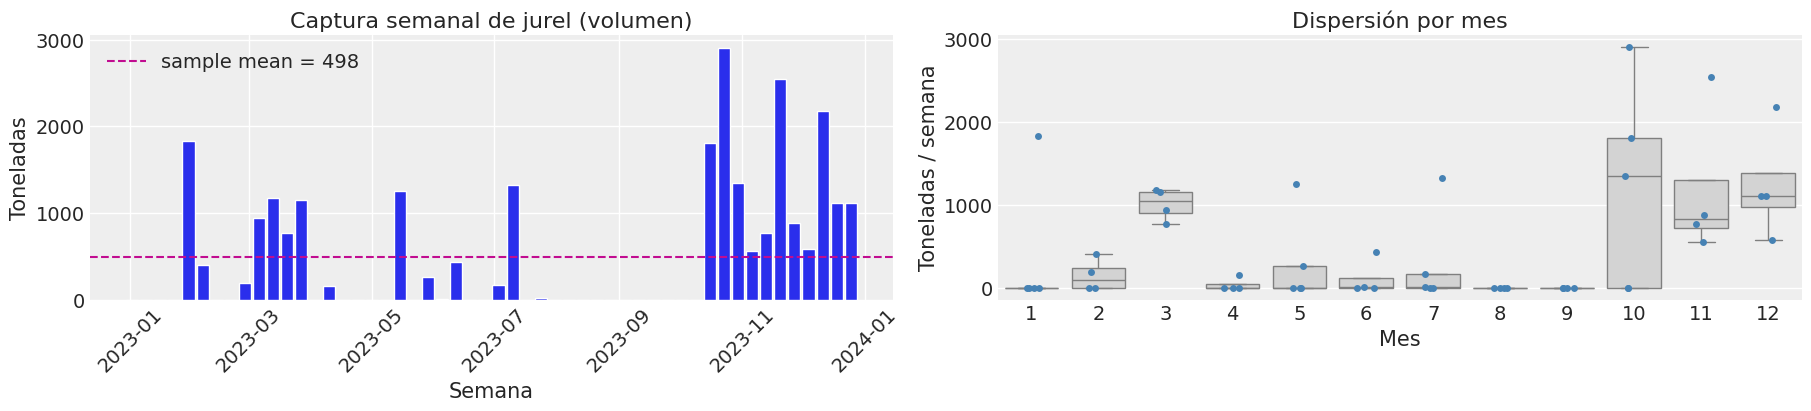

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

# (1) Volumen semanal en el tiempo
axes[0].bar(weekly_data["start_date"], weekly_data["jurel_t"], width=6)
axes[0].set_title("Captura semanal de jurel (volumen)")
axes[0].axhline(weekly_data["jurel_t"].mean(), color="C3", linestyle="--",
           label=f"sample mean = {weekly_data['jurel_t'].mean():.0f}")
axes[0].legend()
axes[0].set_xlabel("Semana"); axes[0].set_ylabel("Toneladas")
axes[0].tick_params(axis="x", rotation=45)

# (2) Dispersión por mes: box + strip (violin si querés densidad)
sns.boxplot(data=weekly_data, x="mes", y="jurel_t", ax=axes[1],
            color="lightgray", fliersize=0)
sns.stripplot(data=weekly_data, x="mes", y="jurel_t", ax=axes[1],
              color="steelblue", size=5, jitter=0.15)
axes[1].set_title("Dispersión por mes")
axes[1].set_xlabel("Mes"); axes[1].set_ylabel("Toneladas / semana")

plt.show()


## 2. Variables

Antes de escribir cualquier expresión matemática, seamos explícitos sobre *qué sabemos* y *qué queremos aprender*.

| Rol | Símbolo | Significado |
|---|---|---|
| **Constante conocida** | $M$ | Cuota anual de jurel para Atacama (toneladas). Dato regulatorio (Subpesca/Sernapesca); no se estima. |
| **Observado** | $X_s$ | Jurel desembarcado en la semana $s$ (toneladas), $X_s \in [0, M]$ — columna `jurel_t`. |
| **Observado (derivado)** | $Y_s = X_s / M$ | Proporción de la cuota anual capturada en la semana $s$, $Y_s \in [0, 1]$. Es la variable de respuesta. |
| **Latente** | $Z_s$ | Indicador binario: $Z_s = 1$ si hubo pesca en la semana $s$, $Z_s = 0$ si la semana fue estructuralmente vacía (veda, fuera de temporada, decisión operativa). |
| **Parámetro** | $\pi \in (0, 1)$ | Probabilidad marginal de que una semana tenga pesca ($Z_s = 1$). |
| **Parámetro** | $\mu \in (0, 1)$ | Proporción media de la cuota capturada **condicional** a $Z_s = 1$. |
| **Parámetro** | $\kappa > 0$ | Concentración de la Beta — controla cuán pegadas a $\mu$ están las semanas activas. Reemplaza el rol que tenía $\sigma$ en la parametrización Normal. |

> **Supuesto — independencia entre semanas.** Modelamos cada $Y_s$ como independiente del resto; la verosimilitud factoriza por semana. Esto implica que la suma acumulada $\sum_s X_s$ no está restringida a $\le M$: el modelo podría asignar masa positiva a trayectorias que superan la cuota anual.

## 3. Historia

> "Cada semana, primero ocurre un evento binario: *¿hubo pesca de jurel?* Con probabilidad $1 - \pi$ la semana es **estructuralmente vacía** ($Y_s = 0$) — veda, fin de temporada, mar cerrado, decisión operativa. Con probabilidad $\pi$ sí hubo pesca, y entonces la fracción de la cuota anual capturada esa semana, $Y_s \in (0, 1)$, fluctúa alrededor de un nivel típico $\mu$, con una concentración $\kappa$ que regula cuán parecidas son las semanas activas entre sí. La cuota anual $M$ es un tope conocido, no algo a estimar; las embarcaciones, el clima y la estacionalidad fina aún no entran al modelo. Las semanas son independientes entre sí."

## 4. Traducción a distribuciones

Formalizamos la historia. Sea $Z_s$ la indicadora de "hubo pesca en la semana $s$" y $Y_s = X_s/M$ la proporción observada. Adoptamos una **Beta cero-inflada** en su forma *hurdle* (la masa en cero y la densidad continua se factorizan en submodelos independientes):

$$
\begin{aligned}
Z_s &\sim \text{Bernoulli}(\pi), \\
Y_s \mid Z_s = 0 &= 0 \quad (\text{degenerada en } 0), \\
Y_s \mid Z_s = 1 &\sim \text{Beta}(\alpha,\, \beta),
\end{aligned}
$$

con la **parametrización media–concentración**

$$
\alpha = \mu\,\kappa, \qquad \beta = (1 - \mu)\,\kappa,
$$

de modo que $\mathbb{E}[Y_s \mid Z_s = 1] = \mu$ y $\text{Var}(Y_s \mid Z_s = 1) = \dfrac{\mu(1-\mu)}{\kappa + 1}$. La verosimilitud completa:

$$
p(Y_s \mid \pi, \mu, \kappa) =
\begin{cases}
1 - \pi & \text{si } Y_s = 0, \\
\pi \cdot \text{Beta}\!\left(Y_s \mid \mu\kappa,\, (1-\mu)\kappa\right) & \text{si } Y_s \in (0, 1).
\end{cases}
$$

Como las dos partes no comparten parámetros, el ajuste factoriza: una **Bernoulli** sobre la indicadora $(Z_s)_s$ usando todas las semanas, y una **Beta** sobre las proporciones $\{Y_s : Y_s > 0\}$ usando sólo las semanas activas.

## 5. Elección de priors

Tres parámetros necesitan priors. Algunos principios:

- **$\pi$ (probabilidad de "hubo pesca" en una semana cualquiera)**: Vive en $(0, 1)$ por construcción. La pesquería de jurel artesanal en Atacama es marcadamente estacional — algunos meses concentran casi toda la actividad y otros tienen el mar prácticamente vacío. Sin asumir cuál de los dos regímenes domina (eso lo aprenderemos de los datos), queremos un prior que reparta masa razonable a lo largo de todo $(0, 1)$ pero que no se pegue a los bordes 0 ni 1, los cuales corresponderían a escenarios degenerados (nunca pesca / siempre pesca).
  - $\pi \sim \text{Beta}(2,\ 2)$ — simétrico, centrado en $0.5$, con desviación ≈ $0.22$. La masa prior cubre casi todo el intervalo $(0, 1)$ pero cae a cero en los extremos. Con incluso unas pocas decenas de semanas observadas, la posterior va a dominar este prior con holgura.

- **$\mu$ (proporción media de la cuota anual capturada en una semana activa)**: Vive en $(0, 1)$ y, por intuición pesquera, debería ser **chica**. Si la temporada activa dura del orden de 20–40 semanas y la captura total se acerca a la cuota anual $M$, una semana activa típica representa entre $1/40 \approx 2.5\%$ y $1/20 = 5\%$ de la cuota — con semanas pico que podrían trepar al 10–20%. Por eso queremos un prior centrado en ese orden de magnitud, asimétrico hacia valores bajos, pero suficientemente amplio para no descartar a priori temporadas más concentradas.
  - $\mu \sim \text{Beta}(2,\ 20)$ — media ≈ $0.09$, desviación ≈ $0.06$. La mayor parte de la masa prior cae entre $0.01$ y $0.25$. Descarta naturalmente valores absurdos como $\mu > 0.5$ (que implicarían capturar más de la mitad de la cuota anual en una sola semana), sin endurecer demasiado el problema si los datos exigieran una temporada concentrada.

- **$\kappa$ (concentración de la Beta condicional)**: Debe ser positivo. Ocupa el rol de "inverso de la dispersión" — para una Beta con media $\mu$, la varianza es $\mu(1-\mu)/(\kappa+1)$. Valores muy chicos ($\kappa < 1$) producen una Beta en forma de **U** (densidad infinita en los bordes), lo cual es implausible: significaría que las semanas activas capturan o casi $0\%$ o casi $100\%$ de la cuota, sin valores intermedios. Valores enormes ($\kappa > 500$) colapsan la Beta a un casi-puntual alrededor de $\mu$, también implausible dada la variabilidad semana a semana que vemos en los datos.
  - $\kappa \sim \text{Gamma}(2,\ 0.1)$ — media $= 20$, desviación ≈ $14$. La masa prior se concentra entre $\approx 5$ y $\approx 50$, evitando los dos extremos patológicos. Con $\mu = 0.1$ y $\kappa = 20$, la desviación condicional de $Y_s$ resulta ≈ $0.065$ — orden razonable para semanas activas que fluctúan entre el 1% y el 25% de la cuota.

**Siempre haga un chequeo predictivo del prior** antes de ajustar: simule datos falsos solo a partir del prior y verifique si son vagamente plausibles — la proporción de semanas con pesca, la magnitud de $Y_s$ en las semanas activas, y la presencia o no de valores patológicos (todo $0$, todo $1$, U-shape). En PyMC: `pm.sample_prior_predictive(...)`.

## 6. Modelo en PyMC

Traducimos la especificación de las secciones 4 y 5 a código. La verosimilitud factoriza en dos submodelos sobre el mismo `pm.Model` (Bernoulli sobre la indicadora de pesca + Beta sobre las semanas activas), de modo que PyMC los ajusta conjuntamente sumando sus log-verosimilitudes.

| Símbolo matemático | Variable PyMC | Tipo |
|---|---|---|
| $M$ | `M` | constante (Python `float`) |
| $X_s$ | `X` | dato observado (`np.ndarray`) |
| $Y_s = X_s/M$ | `Y` | derivada determinista (`np.ndarray`) |
| $Z_s$ | `Z_obs` | dato observado (indicadora 0/1) |
| $\pi$ | `pi` | `pm.Beta` (parámetro) |
| $\mu$ | `mu` | `pm.Beta` (parámetro) |
| $\kappa$ | `kappa` | `pm.Gamma` (parámetro) |
| $\alpha = \mu\kappa$ | `alpha` | `pm.Deterministic` |
| $\beta = (1-\mu)\kappa$ | `beta_` | `pm.Deterministic` (con guión bajo porque `beta` colisiona con `pm.Beta`) |

In [ ]:
# ---------- Datos ----------
M = 10133.5

X = weekly_data["jurel_t"].to_numpy(dtype=float)
assert (X <= M).all(), "Hay semanas con jurel_t > M; revisar el valor de la cuota."

Y = X / M                                             # Y_s = X_s / M  ∈ [0, 1]
Z_obs = (Y > 0).astype(int)                           # indicadora 'hubo pesca'
Y_activas = Y[Y > 0]                                  # Y_s | Z_s = 1  ∈ (0, 1)

print(f"Semanas totales:           {len(Y)}")
print(f"Semanas con pesca (Z=1):   {Z_obs.sum()}  ({Z_obs.mean():.1%})")
print(f"Proporción media activa:   {Y_activas.mean():.4f}")
print(f"Rango Y_s activas:         [{Y_activas.min():.4f}, {Y_activas.max():.4f}]")

Semanas totales:           52
Semanas con pesca (Z=1):   26  (50.0%)
Proporción media activa:   0.0983
Rango Y_s activas:         [0.0013, 0.2867]


In [111]:
coords = {
    "semana": np.arange(len(Y)),
    "semana_activa": np.arange(len(Y_activas)),
}

with pm.Model(coords=coords) as model_0_zib:
    # --- Priors ---
    pi    = pm.Beta("pi",    alpha=2.0, beta=2.0)            # P(Z_s = 1)
    mu    = pm.Beta("mu",    alpha=2.0, beta=20.0)           # E[Y_s | Z_s = 1]
    kappa = pm.Gamma("kappa", alpha=2.0, beta=0.1)            # concentración

    # --- Reparametrización media–concentración de la Beta ---
    alpha = pm.Deterministic("alpha", mu * kappa)
    beta_ = pm.Deterministic("beta",  (1.0 - mu) * kappa)

    # --- Verosimilitud (hurdle, dos partes independientes) ---
    pm.Bernoulli("Z",         p=pi,                    observed=Z_obs,    dims="semana")
    pm.Beta     ("Y_activas", alpha=alpha, beta=beta_, observed=Y_activas, dims="semana_activa")

## 7. Prior predictive check

Antes de muestrear la posterior — operación cara — chequeamos si los priors elegidos producen datos sintéticos *plausibles*. Si simulando sólo desde el prior obtenemos mundos manifiestamente inverosímiles (todas las semanas con pesca o ninguna; $Y_s$ saturadas cerca de 1; densidades Beta en forma de U), los priors están mal calibrados y conviene corregirlos **antes** de invertir tiempo de cómputo en NUTS.

`pm.sample_prior_predictive` toma muestras de la conjunta

$$p(\pi, \mu, \kappa, Z, Y) \;=\; p(\pi)\,p(\mu)\,p(\kappa)\;p(Z, Y \mid \pi, \mu, \kappa)$$

— los priors paramétricos y, propagando por la verosimilitud, también un *dataset falso* por cada draw.

### Qué miramos en los seis paneles

| Panel | Qué muestra | Qué buscamos |
|---|---|---|
| **(1) Prior $\pi$** | Densidad marginal de $\pi$ | Beta(2,2): unimodal, centrada en $0.5$, sin masa en los bordes |
| **(2) Prior $\mu$** | Densidad marginal de $\mu$ | Beta(2,20): asimétrica hacia valores bajos, modo $\approx 0.05$ |
| **(3) Prior $\kappa$** | Densidad marginal de $\kappa$ | Gamma(2, 0.1): positiva, modo $\approx 10$, cola larga |
| **(4) $Y_s$ activas — prior pred. vs observado** | Histograma simulado vs observado | La nube simulada (azul) debe **cubrir cómodamente** la observada (roja) — si el observado cae fuera del soporte del prior pred., el prior es demasiado restrictivo |
| **(5) Fracción $\bar Z$ de semanas con pesca** | Distribución prior pred. de $\frac{1}{S}\sum_s Z_s$ | El valor observado (línea roja) debe caer dentro del rango plausible — no en una cola extrema |
| **(6) Curvas Beta implícitas** | 30 densidades $\text{Beta}(\alpha,\beta)$ sorteadas del prior conjunto $(\mu,\kappa)$ | Mayoría unimodales con modo cerca de $\mu$ — si dominan formas en **U** (explotando en los bordes) o casi-puntuales, el prior sobre $\kappa$ es problemático |

> Veredicto operativo: si el observado cae fuera del soporte del prior pred. en algún panel, **no** seguimos con NUTS — volvemos a la sección 5 y reajustamos los hiperparámetros antes.

Sampling: [Y_activas, Z, kappa, mu, pi]
/tmp/ipykernel_29/3098131660.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


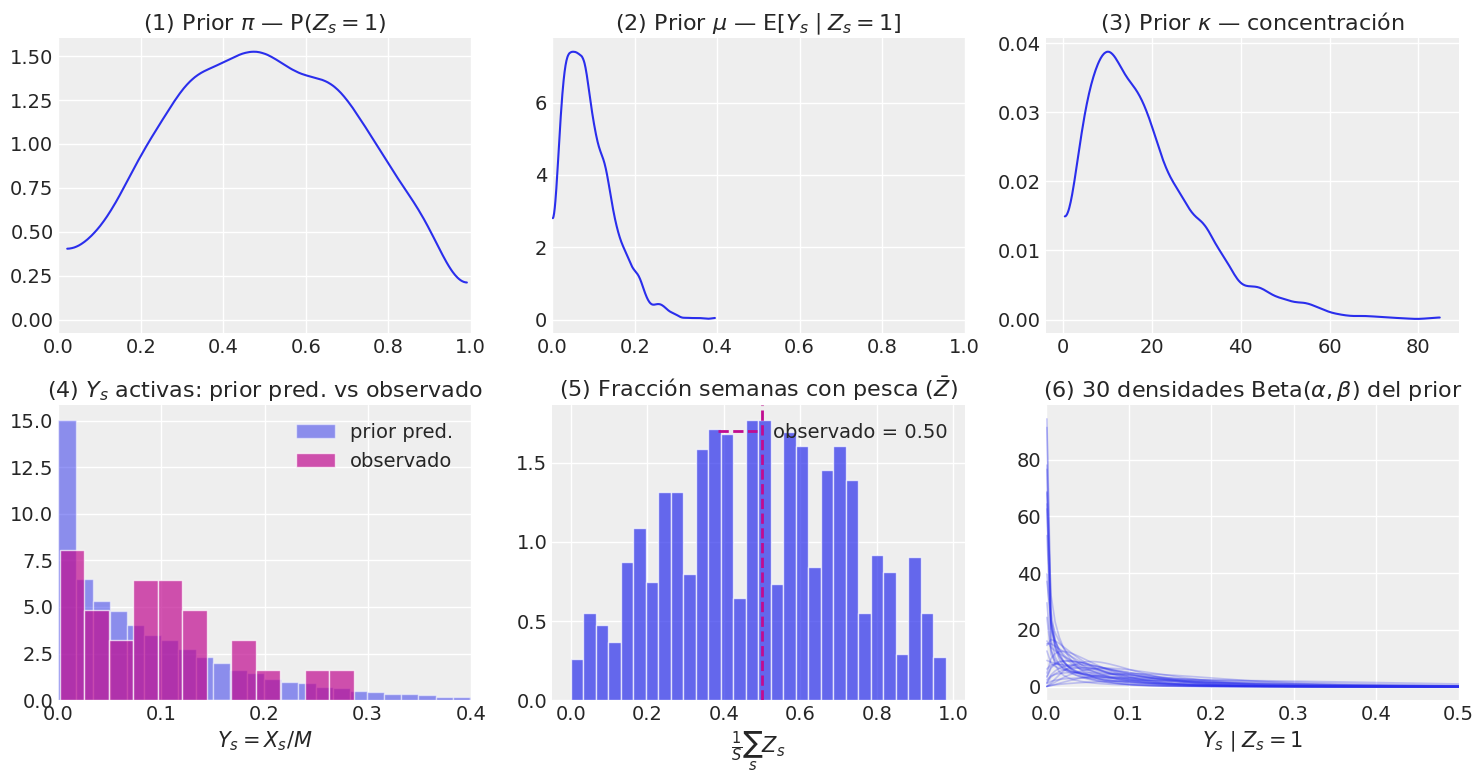

Y_activas observadas:   media=0.0983, max=0.2867
Y_activas prior pred.:  media=0.0915, max=0.4541 (q99)
Z̄ observado:            0.500
Z̄ prior pred. (HDI 94%): [0.077, 0.904]


In [112]:
import scipy.stats as stats

# ---------- Muestreo del prior + prior predictive ----------
with model_0_zib:
    idata_prior = pm.sample_prior_predictive(draws=2000, random_seed=42)

prior      = idata_prior.prior
prior_pred = idata_prior.prior_predictive

# Aplanamos (chain, draw) -> 1D
pi_draws    = prior["pi"].values.flatten()
mu_draws    = prior["mu"].values.flatten()
kappa_draws = prior["kappa"].values.flatten()
alpha_draws = prior["alpha"].values.flatten()
beta_draws  = prior["beta"].values.flatten()

# ---------- Panel 2×3 ----------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# === Fila 1: priors marginales ===
az.plot_dist(pi_draws,    ax=axes[0, 0], color="C0")
axes[0, 0].set_title(r"(1) Prior $\pi$ — P($Z_s = 1$)")
axes[0, 0].set_xlim(0, 1)

az.plot_dist(mu_draws,    ax=axes[0, 1], color="C0")
axes[0, 1].set_title(r"(2) Prior $\mu$ — E[$Y_s \mid Z_s = 1$]")
axes[0, 1].set_xlim(0, 1)

az.plot_dist(kappa_draws, ax=axes[0, 2], color="C0")
axes[0, 2].set_title(r"(3) Prior $\kappa$ — concentración")

# === Fila 2 ===
# (4) Y_s activas: prior pred. vs observado
y_pred = prior_pred["Y_activas"].values.flatten()
axes[1, 0].hist(y_pred,    bins=60, density=True, alpha=0.5, color="C0", label="prior pred.")
axes[1, 0].hist(Y_activas, bins=12, density=True, alpha=0.7, color="C3", label="observado")
axes[1, 0].set_xlim(0, 0.4)
axes[1, 0].set_title(r"(4) $Y_s$ activas: prior pred. vs observado")
axes[1, 0].set_xlabel(r"$Y_s = X_s / M$")
axes[1, 0].legend()

# (5) Fracción simulada de semanas con pesca
n_weeks = len(Y)
sim_z_frac = rng.binomial(n_weeks, pi_draws) / n_weeks
axes[1, 1].hist(sim_z_frac, bins=30, density=True, color="C0", alpha=0.7)
axes[1, 1].axvline(Z_obs.mean(), color="C3", linestyle="--", lw=2,
                   label=f"observado = {Z_obs.mean():.2f}")
axes[1, 1].set_title(r"(5) Fracción semanas con pesca ($\bar Z$)")
axes[1, 1].set_xlabel(r"$\frac{1}{S}\sum_s Z_s$")
axes[1, 1].legend()

# (6) Curvas Beta implícitas — 30 muestras del prior conjunto (mu, kappa)
xs = np.linspace(0.001, 0.999, 200)
idx = rng.choice(len(alpha_draws), size=30, replace=False)
for i in idx:
    axes[1, 2].plot(xs, stats.beta.pdf(xs, alpha_draws[i], beta_draws[i]),
                    color="C0", alpha=0.25, lw=1.2)
axes[1, 2].set_title(r"(6) 30 densidades $\mathrm{Beta}(\alpha,\beta)$ del prior")
axes[1, 2].set_xlabel(r"$Y_s \mid Z_s = 1$")
axes[1, 2].set_xlim(0, 0.5)

plt.tight_layout()
plt.show()

# ---------- Resumen numérico ----------
print(f"Y_activas observadas:   media={Y_activas.mean():.4f}, max={Y_activas.max():.4f}")
print(f"Y_activas prior pred.:  media={y_pred.mean():.4f}, max={np.quantile(y_pred, 0.99):.4f} (q99)")
print(f"Z̄ observado:            {Z_obs.mean():.3f}")
print(f"Z̄ prior pred. (HDI 94%): [{np.quantile(sim_z_frac, 0.03):.3f}, {np.quantile(sim_z_frac, 0.97):.3f}]")

## 8. Inferencia: muestreo de la posteriori

Pasado el prior predictive sin sorpresas, ajustamos. Usamos **NUTS** (*No-U-Turn Sampler*), el algoritmo HMC por defecto de PyMC, muy eficiente para parámetros continuos como los nuestros — $\pi, \mu \in (0,1)$ y $\kappa > 0$, todos reparametrizados internamente por PyMC al espacio real sin restricciones (logit y log respectivamente) para que el gradiente esté bien definido en todo el dominio.

### Configuración del sampler

| Argumento | Valor | Por qué |
|---|---|---|
| `draws` | 2000 | Muestras retenidas por cadena, después del tuning |
| `tune` | 1500 | Pasos de calentamiento — NUTS adapta el paso del integrador y la métrica de masa en esta fase, y esas muestras se descartan |
| `chains` | 4 | Necesitamos al menos 2 cadenas para calcular R-hat; 4 es el estándar de oro |
| `target_accept` | 0.95 | Tasa de aceptación objetivo; elevarla de 0.8 (default) a 0.95 reduce el paso del integrador, evitando divergencias cerca de los bordes de la Beta |
| `random_seed` | 42 | Reproducibilidad |

### Lo que devuelve

Un `arviz.InferenceData` con varios grupos:

- `idata.posterior` — muestras conjuntas de $(\pi, \mu, \kappa, \alpha, \beta)$.
- `idata.sample_stats` — diagnósticos por draw (divergencias, paso del integrador, energía, log-prob).
- `idata.observed_data` — los datos `Z` y `Y_activas` que pasamos al modelo.

### Qué chequeamos inmediatamente

1. **`az.summary`** — tabla con media, sd, HDI 94%, **R-hat** (debe ser $\le 1.01$) y **ESS** (effective sample size; idealmente $> 400$ por parámetro). Si R-hat $> 1.01$ o ESS muy bajo, las cadenas no convergieron y hay que investigar antes de interpretar.
2. **Trace plot** — cuatro cadenas superpuestas. Deberían verse como "ruido blanco" sin tendencias, saltos ni regiones donde una cadena se queda atascada. Las densidades marginales de las cuatro cadenas, a la izquierda del trace, deberían superponerse casi perfectamente.

In [113]:
# ---------- Muestreo de la posteriori con NUTS ----------
with model_0_zib:
    idata = pm.sample(
        draws=2000,
        tune=1500,
        chains=4,
        target_accept=0.95,
        random_seed=42,
        progressbar=True,
    )

# Resumen + diagnósticos básicos
az.summary(
    idata,
    var_names=["pi", "mu", "kappa", "alpha", "beta"],
    hdi_prob=0.94,
).round(3)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi, mu, kappa]


Output()

Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 1 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi,0.500,0.066,0.379,0.627,0.001,0.001,6219.0,5131.0,1.0
mu,0.096,0.016,0.069,0.127,0.000,0.000,5709.0,5265.0,1.0
kappa,11.435,3.062,6.114,17.273,0.041,0.037,5469.0,5296.0,1.0
alpha,1.078,0.255,0.643,1.573,0.003,0.003,6714.0,5792.0,1.0
beta,10.358,2.860,5.546,16.000,0.039,0.035,5396.0,5118.0,1.0


/tmp/ipykernel_29/168723923.py:8: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


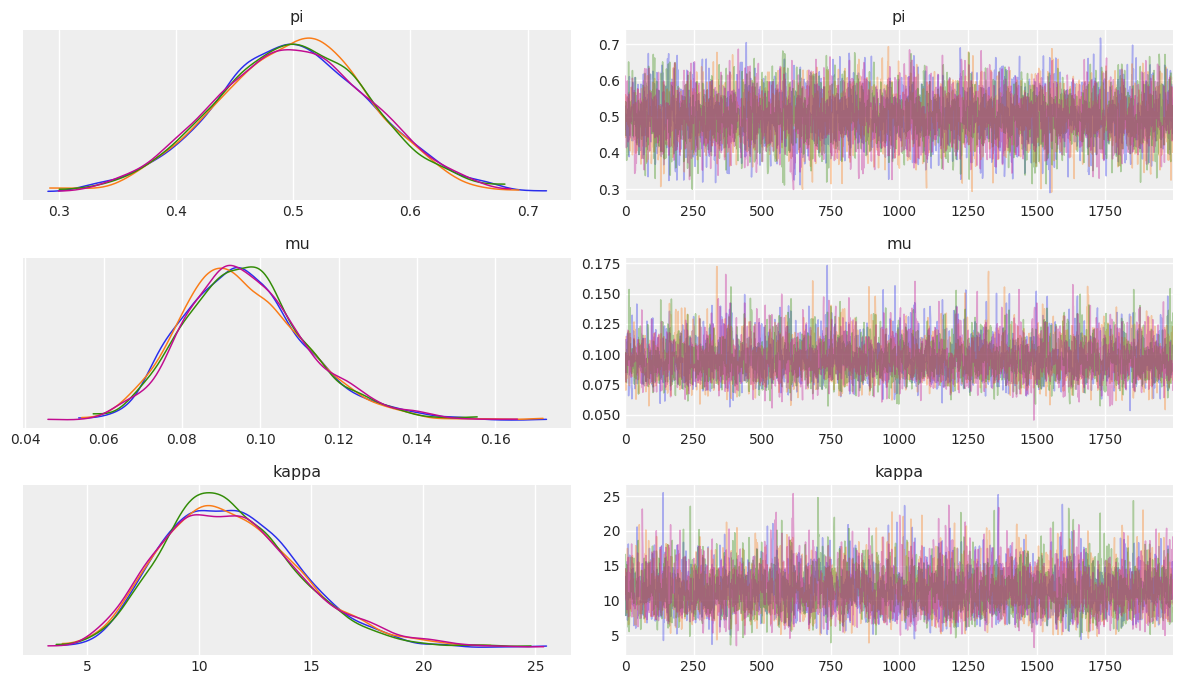

Divergencias totales: 0  (idealmente 0)


In [114]:
# Trace plot — chequeo visual de mezcla entre cadenas
az.plot_trace(
    idata,
    var_names=["pi", "mu", "kappa"],
    figsize=(12, 7),
    compact=False,
)
plt.tight_layout()
plt.show()

# Diagnósticos de fondo del sampler
n_divergences = idata.sample_stats["diverging"].sum().item()
print(f"Divergencias totales: {n_divergences}  (idealmente 0)")

## 9. Diagnósticos posteriores

La sección 8 nos dio el primer pase: R-hat $\le 1.01$, ESS razonable, trace sin patologías visibles, cero divergencias. Eso descarta los modos de falla obvios, pero hay diagnósticos más finos que conviene mirar antes de declarar "modelo ajustado". Si alguno falla, **no usamos esta posterior** — hay que entender la patología y posiblemente reparametrizar o ajustar el sampler.

### Diagnósticos que vamos a producir

| Diagnóstico | Qué detecta | Qué buscamos |
|---|---|---|
| **Rank plot** | Diferencias sutiles entre cadenas que el trace puede ocultar | Histogramas **uniformes** — cadenas estadísticamente indistinguibles |
| **Plot de energía** | Mala exploración geométrica del HMC (BFMI bajo) | Densidad de energía marginal y de transición casi **superpuestas**; BFMI $> 0.3$ |
| **Pair plot** $(\mu, \kappa)$ | Correlaciones fuertes o formas patológicas (funnel, banana) | Nube razonablemente isotrópica o levemente correlacionada; **sin embudos** |
| **Autocorrelación** | Cadenas con memoria larga (ESS bajo encubierto en el resumen) | Caída rápida hacia 0 dentro de ~10–20 lags |

### Por qué nos interesa especialmente $\mu$ vs $\kappa$

En la parametrización media-concentración de la Beta, $\mu$ y $\kappa$ pueden quedar acoplados — la verosimilitud restringe los productos $\mu\kappa$ y $(1-\mu)\kappa$, no a cada parámetro por separado. Una correlación moderada es esperable. Pero un **funnel** (la nube se estrecha cuando $\kappa$ es chico, replicando el funnel de Neal) sería una señal de problemas geométricos que motivaría reparametrizar — por ejemplo, muestrear $\log \kappa$ explícitamente o usar una parametrización $\alpha, \beta$ directa con priors sobre las shapes.

### Sobre BFMI (Bayesian Fraction of Missing Information)

Es una medida de cuán bien NUTS está explorando los niveles de energía: BFMI $< 0.3$ típicamente delata colas pesadas mal exploradas; BFMI $> 0.5$ es señal de exploración saludable.

/tmp/ipykernel_29/727919968.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


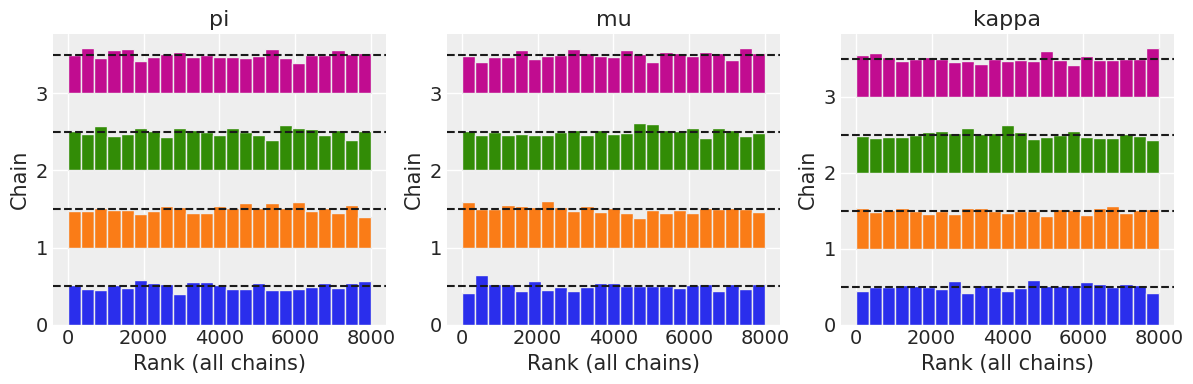

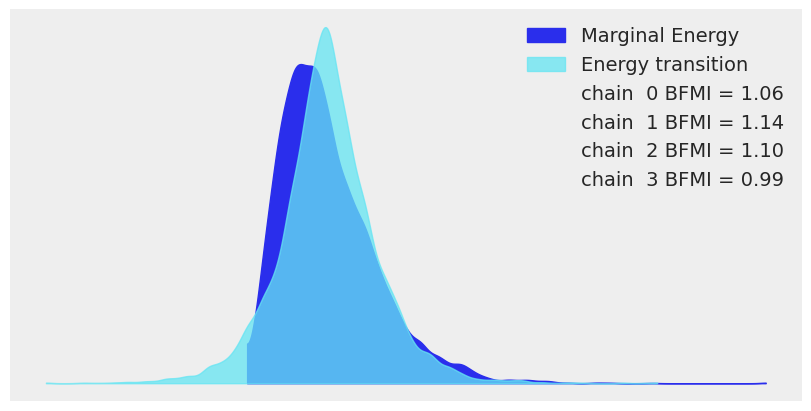

BFMI por cadena: [1.059 1.135 1.096 0.986]
  (BFMI < 0.3 indica problemas de exploración; > 0.5 es saludable.)


In [115]:
# ---------- Rank plots ----------
# Las cuatro cadenas deberían producir histogramas casi uniformes.
# Asimetrías o picos delatan no-mezcla aunque R-hat parezca bueno.
az.plot_rank(idata, var_names=["pi", "mu", "kappa"], figsize=(12, 4))
plt.tight_layout()
plt.show()

# ---------- Energy plot + BFMI ----------
az.plot_energy(idata, figsize=(8, 4))
plt.show()

bfmi = az.bfmi(idata)
print(f"BFMI por cadena: {np.round(bfmi, 3)}")
print(f"  (BFMI < 0.3 indica problemas de exploración; > 0.5 es saludable.)")

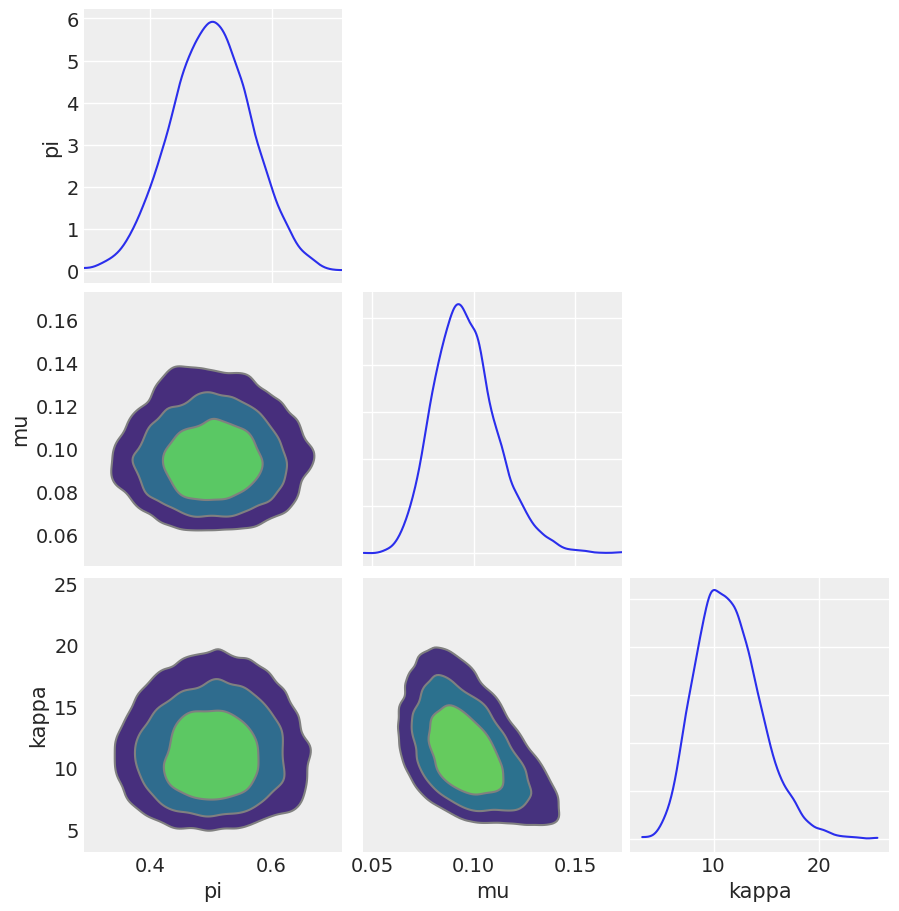

/tmp/ipykernel_29/1498846892.py:16: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


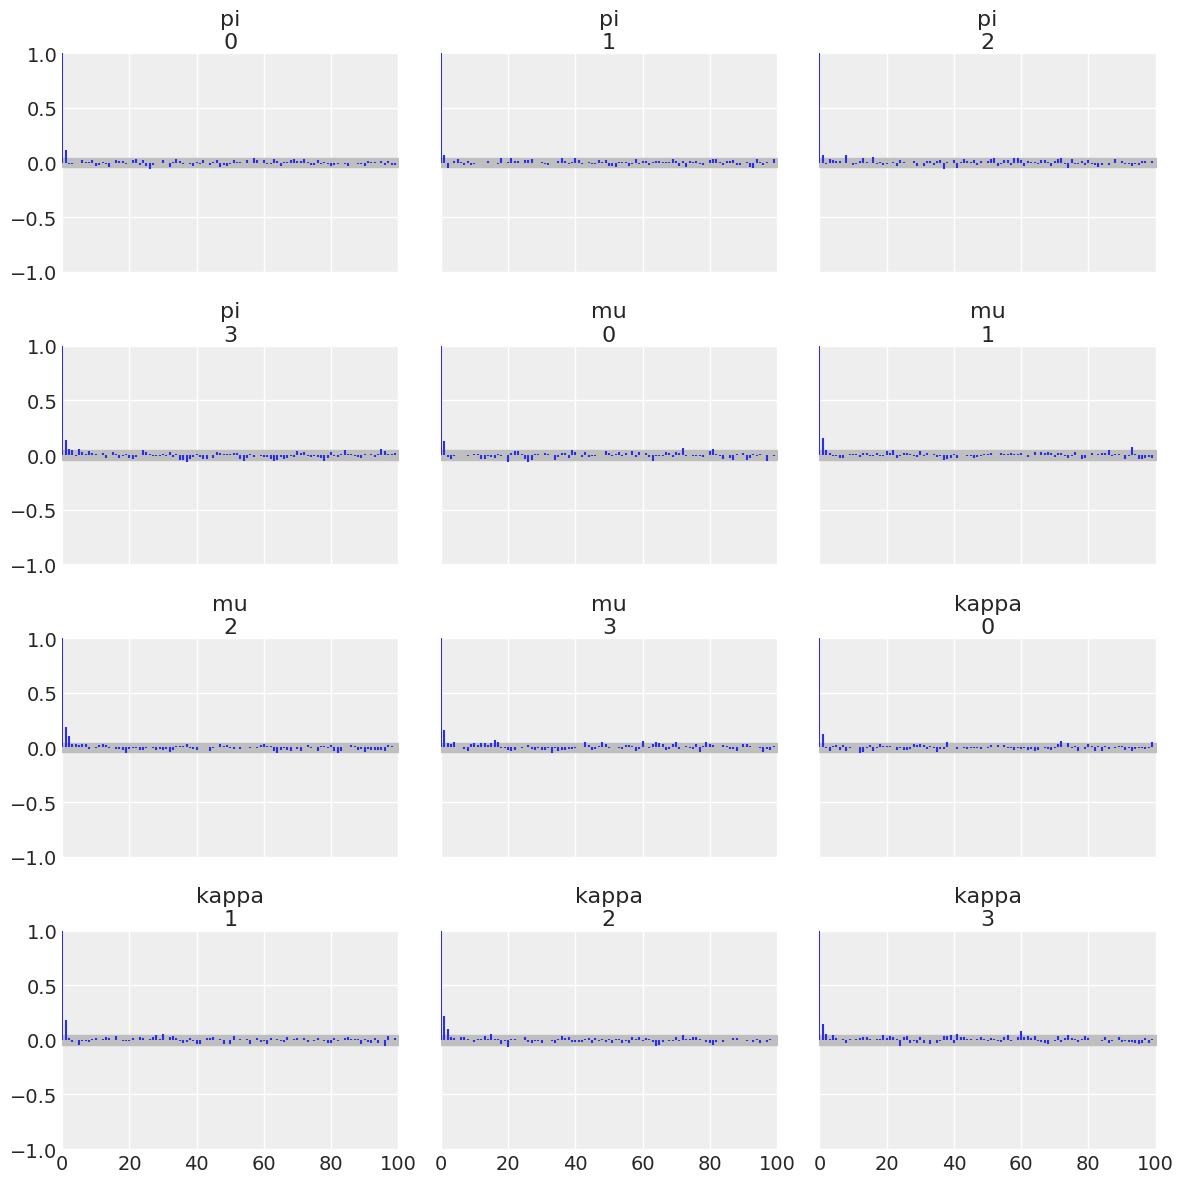

In [116]:
# ---------- Pair plot ----------
# Buscamos: ¿hay funnel μ–κ? ¿Correlaciones extremas?
# El acoplamiento moderado de μ y κ es esperable en la Beta media–concentración.
az.plot_pair(
    idata,
    var_names=["pi", "mu", "kappa"],
    kind="kde",
    marginals=True,
    figsize=(9, 9),
)
plt.show()

# ---------- Autocorrelación ----------
# Caída rápida hacia 0 → cadenas decorrelacionadas, ESS confiable.
az.plot_autocorr(idata, var_names=["pi", "mu", "kappa"], figsize=(12, 12))
plt.tight_layout()
plt.show()